In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
generator_llm = ChatOpenAI(model='gpt-4o')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o')

In [3]:
#state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int


In [4]:
#schema
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [5]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [6]:
def generate(state: TweetState):
    messages = [ 
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f""" Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
        Rules: - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references. 
        - Think in meme logic, punchlines, or relatable takes. 
        - Use simple, day to day english - This is version {state['iteration'] + 1}.
    """)
    ]
    response = generator_llm.invoke(messages).content 

    return{'tweet': response}


In [7]:
def evaluate(state: TweetState):
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
    ]
    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation': response.evaluation, 'feedback': response.feedback}


In [8]:
def optimize(state: TweetState):
    messages = [
        SystemMessage(content="You are a tweet optimizer. Rewrite the tweet to be funnier and more viral."),
        HumanMessage(content=f"""Improve this tweet about "{state['topic']}":

Original tweet: "{state['tweet']}"

Feedback: {state['feedback']}

Write a better version. Max 280 characters.""")
    ]
    response = optimizer_llm.invoke(messages).content
    return {'tweet': response, 'iteration': state['iteration'] + 1}


In [10]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

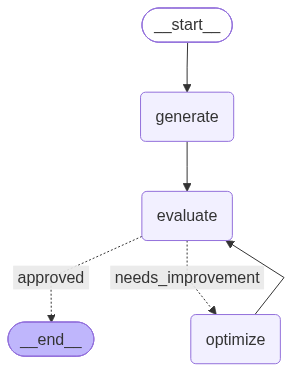

In [11]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate)
graph.add_node('evaluate', evaluate)
graph.add_node('optimize', optimize)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [12]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-or-v1*************************************************************38a4. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [13]:
result

NameError: name 'result' is not defined

In [14]:
for tweet in result['tweet_history']:
    print(tweet)

NameError: name 'result' is not defined